# Bring your own model: using `xwmt` without MOM6

`xwmt` is usually demonstrated on MOM6 output, and the `xbudget` presets that ship with it
describe MOM6's diagnostics in particular. None of that is hardcoded. `xwmt` only ever sees an
`xgcm.Grid` and a plain Python recipe that names your variables, so it works just as well on
MITgcm, NEMO, POP, Oceananigans, an idealized model of your own, or a gridded observational
product.

This notebook shows how to get there from a bare `xarray.Dataset`.

## What you'll learn

1. How to build an `xgcm.Grid` by hand from a plain `xarray.Dataset`, with your own variable names.
2. How `xwmt` turns depth into pressure, and what `gravity=` controls.
3. How to extend an existing grid with `xwmt.add_gridcoords`.
4. How to hand-write an `xbudget` recipe term by term, with no preset.
5. How to choose an equation of state with `eos=`, including bringing your own.
6. How to declare what kind of temperature and salinity your model actually outputs (`t_var`/`s_var`).
7. How to use `WaterMass` on its own, when you want density and $\alpha$/$\beta$ but not transformations.
8. How to use a generic tracer, such as oxygen, as the transformation coordinate $\lambda$.

## Prerequisites

Read `quickstart.ipynb` first. It covers what a water mass transformation *is* and what
`integrate_transformations` returns; this notebook assumes both, and focuses purely on the
plumbing needed to point `xwmt` at non-MOM6 data.

**No download, no network.** Every dataset here is built analytically in a few lines of `numpy`.

## Imports

In [1]:
import numpy as np
import xarray as xr
import xgcm
import matplotlib.pyplot as plt

import xeos
import xwmt

## 1. Building an `xgcm.Grid` by hand

`xwmt`'s only structural input is an `xgcm.Grid`. The grid carries two things: a description of
the discretization (which coordinate holds the centre of a cell and which holds its edges, along
each axis), and the dataset itself, reachable as `grid._ds`.

To prove that nothing about MOM6 is baked in, we deliberately use variable names that no MOM6 user
would recognize: `temp` and `salt` instead of `thetao` and `so`, `dz` instead of `thkcello`, `area`
instead of `areacello`, and `depth_c`/`depth_g` instead of `z_l`/`z_i`.

The physical setup is a small North-Atlantic-like basin: a lon/lat box from 60°W to 0° and 20°N to
70°N, 4000 m deep, with warm salty subtropics, a cold fresh subpolar gyre, and a thermocline. The
fields are analytic profiles rather than model output, but they behave enough like the real thing
to produce recognizable transformation rates.

In [2]:
R_EARTH = 6.371e6  # [m]

nx, ny, nz = 30, 30, 20


def centers(edges):
    """Cell centres from cell edges."""
    return 0.5 * (edges[:-1] + edges[1:])


# Cell edges ("g" for grid/interface), stretched in the vertical so that layers are
# thin near the surface, where the transformation actually happens.
lon_g = np.linspace(-60.0, 0.0, nx + 1)
lat_g = np.linspace(20.0, 70.0, ny + 1)
depth_g = 4000.0 * np.linspace(0.0, 1.0, nz + 1) ** 2

# Cell centres ("c").
lon_c, lat_c, depth_c = centers(lon_g), centers(lat_g), centers(depth_g)

ds = xr.Dataset(
    coords={
        "lon_c": ("lon_c", lon_c),
        "lat_c": ("lat_c", lat_c),
        "depth_c": ("depth_c", depth_c),
        "lon_g": ("lon_g", lon_g),
        "lat_g": ("lat_g", lat_g),
        "depth_g": ("depth_g", depth_g),
    }
)

# Geographic position as 2-D fields, the way curvilinear model output carries it.
# `xwmt` needs these for exactly one thing: converting practical to absolute salinity,
# which TEOS-10 requires. An EOS that takes practical salinity directly (section 4)
# never asks for them, and you can leave them out entirely in that case -- if a
# conversion does need them, `xwmt` says so by name. They are 2-D here even though this
# grid is a plain lon/lat box, so that the shapes match what a real model would give you.
ds = ds.assign_coords(
    {
        "lon": (("lat_c", "lon_c"), np.broadcast_to(lon_c[np.newaxis, :], (ny, nx)).copy()),
        "lat": (("lat_c", "lon_c"), np.broadcast_to(lat_c[:, np.newaxis], (ny, nx)).copy()),
    }
)

ds

<xarray.Dataset> Size: 16kB
Dimensions:  (lon_c: 30, lat_c: 30, depth_c: 20, lon_g: 31, lat_g: 31,
              depth_g: 21)
Coordinates:
  * lon_c    (lon_c) float64 240B -59.0 -57.0 -55.0 -53.0 ... -5.0 -3.0 -1.0
    lon      (lat_c, lon_c) float64 7kB -59.0 -57.0 -55.0 ... -5.0 -3.0 -1.0
    lat      (lat_c, lon_c) float64 7kB 20.83 20.83 20.83 ... 69.17 69.17 69.17
  * lat_c    (lat_c) float64 240B 20.83 22.5 24.17 25.83 ... 65.83 67.5 69.17
  * depth_c  (depth_c) float64 160B 5.0 25.0 65.0 ... 3.425e+03 3.805e+03
  * lon_g    (lon_g) float64 248B -60.0 -58.0 -56.0 -54.0 ... -6.0 -4.0 -2.0 0.0
  * lat_g    (lat_g) float64 248B 20.0 21.67 23.33 25.0 ... 66.67 68.33 70.0
  * depth_g  (depth_g) float64 168B 0.0 10.0 40.0 ... 3.24e+03 3.61e+03 4e+03
Data variables:
    *empty*

### Grid metrics

A *metric* tells `xgcm` how to turn a count of cells into a physical measure. `xwmt` needs the
horizontal cell area, because a transformation rate is an integral of a flux over the region where
$\lambda$ falls inside a given bin. We supply it as a single `("X", "Y")` metric.

Layer thickness is handled separately: `xwmt` learns about it from the `xbudget` recipe
(section 3), not from the grid metrics.

In [3]:
# Cell area on a sphere [m2].
area = (
    R_EARTH**2
    * np.cos(np.deg2rad(lat_c))[:, np.newaxis]
    * np.deg2rad(np.diff(lon_g))[np.newaxis, :]
    * np.deg2rad(np.diff(lat_g))[:, np.newaxis]
)
ds["area"] = (("lat_c", "lon_c"), area)

# Layer thickness [m]. Uniform in the horizontal here, but it need not be.
DIMS = ("depth_c", "lat_c", "lon_c")
ds["dz"] = (DIMS, np.broadcast_to(np.diff(depth_g)[:, None, None], (nz, ny, nx)).copy())

# Broadcast helpers: depth varies along axis 0, latitude along axis 1.
z3 = depth_c[:, np.newaxis, np.newaxis]
lat3 = lat_c[np.newaxis, :, np.newaxis]

# Tracers: warm salty subtropics, cold fresh subpolar gyre, over a thermocline.
sst = 2.0 + 26.0 * np.cos(np.deg2rad((lat3 - 20.0) * 90.0 / 50.0))
sss = 34.5 + 2.0 * np.exp(-(((lat3 - 30.0) / 12.0) ** 2))

ds["temp"] = (DIMS, np.broadcast_to(2.0 + (sst - 2.0) * np.exp(-z3 / 500.0), (nz, ny, nx)).copy())
ds["salt"] = (DIMS, np.broadcast_to(34.8 + (sss - 34.8) * np.exp(-z3 / 800.0), (nz, ny, nx)).copy())

ds

<xarray.Dataset> Size: 455kB
Dimensions:  (lon_c: 30, lat_c: 30, depth_c: 20, lon_g: 31, lat_g: 31,
              depth_g: 21)
Coordinates:
  * lon_c    (lon_c) float64 240B -59.0 -57.0 -55.0 -53.0 ... -5.0 -3.0 -1.0
    lon      (lat_c, lon_c) float64 7kB -59.0 -57.0 -55.0 ... -5.0 -3.0 -1.0
    lat      (lat_c, lon_c) float64 7kB 20.83 20.83 20.83 ... 69.17 69.17 69.17
  * lat_c    (lat_c) float64 240B 20.83 22.5 24.17 25.83 ... 65.83 67.5 69.17
  * depth_c  (depth_c) float64 160B 5.0 25.0 65.0 ... 3.425e+03 3.805e+03
  * lon_g    (lon_g) float64 248B -60.0 -58.0 -56.0 -54.0 ... -6.0 -4.0 -2.0 0.0
  * lat_g    (lat_g) float64 248B 20.0 21.67 23.33 25.0 ... 66.67 68.33 70.0
  * depth_g  (depth_g) float64 168B 0.0 10.0 40.0 ... 3.24e+03 3.61e+03 4e+03
Data variables:
    area     (lat_c, lon_c) float64 7kB 3.852e+10 3.852e+10 ... 1.466e+10
    dz       (depth_c, lat_c, lon_c) float64 144kB 10.0 10.0 ... 390.0 390.0
    temp     (depth_c, lat_c, lon_c) float64 144kB 27.73 27.73 27.73 ... 2.0 2.0
    salt     (depth_c, lat_c, lon_c) float64 144kB 35.61 35.61 ... 34.8 34.8

### Coordinates and padding

`coords` maps each `xgcm` axis onto the dataset coordinates that hold its cell centres and cell
edges. `xwmt` requires all three of `"X"`, `"Y"` and `"Z"`, and for the `"Z"` axis it needs both a
`center` and an `outer` position. The `outer` coordinate has one more point than the `center` one
(`nz + 1` interfaces bounding `nz` layers), which is what lets `xwmt` difference interfacial fluxes
and accumulate thicknesses without ambiguity at the surface and the sea floor.

`padding` tells `xgcm` what to assume just outside the domain when it differences or interpolates
across a boundary. Our basin is a lon/lat box, so `"extend"` (repeat the edge value, i.e. a
zero-gradient boundary) is the honest choice in `Y` and `Z`; we use `"periodic"` in `X` merely to
illustrate the option.

In [4]:
coords = {
    "X": {"center": "lon_c", "outer": "lon_g"},
    "Y": {"center": "lat_c", "outer": "lat_g"},
    "Z": {"center": "depth_c", "outer": "depth_g"},
}
metrics = {("X", "Y"): "area"}
padding = {"X": "periodic", "Y": "extend", "Z": "extend"}

grid = xgcm.Grid(ds, coords=coords, metrics=metrics, padding=padding, autoparse_metadata=False)
grid

<xgcm.Grid>
X Axis (periodic, padding='periodic'):
  * center   lon_c --> outer
  * outer    lon_g --> center
Y Axis (not periodic, padding='extend'):
  * center   lat_c --> outer
  * outer    lat_g --> center
Z Axis (not periodic, padding='extend'):
  * center   depth_c --> outer
  * outer    depth_g --> center

### A first density

That is the whole structural input. `xwmt.WaterMass` can already derive density and the
expansion/contraction coefficients from it — no budget recipe required.

One keyword is worth meeting now. Every equation of state takes *pressure*, but a model grid
knows *depth*, so `xwmt` converts between them. `gravity` controls how: it defaults to a
constant `9.81` m s$^{-2}$, giving the Boussinesq hydrostatic pressure
$p = \rho_{0}\,g\,\text{depth}$ that most ocean models assume internally. Pass
`gravity="gsw"` instead for `gsw.p_from_z`, whose gravity varies with latitude; that path
needs a `lat` coordinate on the dataset. The two differ by well under 1% of the pressure, but
the constant is both the commoner modelling assumption and the one that asks less of your grid.

In [5]:
wm = xwmt.WaterMass(
    grid, t_name="temp", s_name="salt", h_name="dz",
    t_var="potential", s_var="practical",
)
wm.get_density("sigma0")

<xarray.DataArray 'sigma0' (depth_c: 20, lat_c: 30, lon_c: 30)> Size: 144kB
dask.array<sub, shape=(20, 30, 30), dtype=float64, chunksize=(20, 30, 30), chunktype=numpy.ndarray>
Coordinates:
  * depth_c  (depth_c) float64 160B 5.0 25.0 65.0 ... 3.425e+03 3.805e+03
  * lat_c    (lat_c) float64 240B 20.83 22.5 24.17 25.83 ... 65.83 67.5 69.17
  * lon_c    (lon_c) float64 240B -59.0 -57.0 -55.0 -53.0 ... -5.0 -3.0 -1.0
    lon      (lat_c, lon_c) float64 7kB -59.0 -57.0 -55.0 ... -5.0 -3.0 -1.0
    lat      (lat_c, lon_c) float64 7kB 20.83 20.83 20.83 ... 69.17 69.17 69.17
Attributes:
    long_name:  potential density anomaly (referenced to 0 dbar)
    units:      kg m-3

## 2. Extending a grid with `xwmt.add_gridcoords`

Rebuilding a grid by hand, as we just did, means re-typing `coords`, `metrics` and `padding` and
hoping you got them all right. When all you want is to *add* an axis to a grid that already exists,
`xwmt.add_gridcoords(grid, coords, padding)` does it for you: it copies the existing axes, metrics
and padding from the source grid, merges in the extras, and returns a new grid.

A realistic case: you start from a surface-only dataset, so your grid has only `X` and `Y`. Later
you obtain the vertical structure and need a `Z` axis.

In [6]:
ds_2d = xr.Dataset(
    coords={
        "lon_c": ("lon_c", lon_c), "lat_c": ("lat_c", lat_c),
        "lon_g": ("lon_g", lon_g), "lat_g": ("lat_g", lat_g),
        # The vertical coordinates are present in the dataset, but not yet wired up
        # as an xgcm axis.
        "depth_c": ("depth_c", depth_c), "depth_g": ("depth_g", depth_g),
    }
)
ds_2d["area"] = (("lat_c", "lon_c"), area)

grid_2d = xgcm.Grid(
    ds_2d,
    coords={"X": {"center": "lon_c", "outer": "lon_g"},
            "Y": {"center": "lat_c", "outer": "lat_g"}},
    metrics={("X", "Y"): "area"},
    padding={"X": "periodic", "Y": "extend"},
    autoparse_metadata=False,
)
print("axes before:", list(grid_2d.axes))

axes before: ['X', 'Y']


In [7]:
grid_3d = xwmt.add_gridcoords(
    grid_2d,
    coords={"Z": {"center": "depth_c", "outer": "depth_g"}},
    padding={"Z": "extend"},
)

print("axes after: ", list(grid_3d.axes))
print("metrics carried over:", {tuple(sorted(k)): [m.name for m in v]
                                for k, v in grid_3d._metrics.items()})
print("padding carried over:", {ax: grid_3d.axes[ax].padding for ax in grid_3d.axes})
print("source grid untouched:", list(grid_2d.axes))

axes after:  ['X', 'Y', 'Z']
metrics carried over: {('X', 'Y'): ['area']}
padding carried over: {'X': 'periodic', 'Y': 'extend', 'Z': 'extend'}
source grid untouched: ['X', 'Y']


The new axis is added, and the `("X", "Y")` area metric and the per-axis padding are preserved
without our restating them. The source grid keeps its own axes, so `add_gridcoords` is safe to call
on a grid you intend to keep using.

## 3. Hand-writing the `xbudget` recipe

This is the step that blocks most non-MOM6 users. `xbudget.load_preset_budget(model="MOM6")`
returns a large nested recipe describing MOM6's diagnostics, and it is tempting to assume some
equivalent machinery is required for your model. It is not. By the time `xwmt` sees it, the
recipe is just a dict, and for a handful of terms you should write it out yourself.

The structure is:

```python
{
    "mass":   {"thickness": <thickness variable>},
    <tracer>: {"lambda": <tracer variable>,
               "lhs": {<process name>: <tendency variable>, ...},
               "rhs": {<process name>: <tendency variable>, ...}},
}
```

- `mass` must be present. Its `thickness` entry names the layer thickness variable — our `dz`.
  (`thickness` itself is optional; omitting it is for surface-only analyses.)
- `lambda` names the variable that plays the role of the transformation coordinate $\lambda$ for
  that tracer: the field you bin in.
- `lhs` and `rhs` refer to the two sides of the tracer budget
  $\partial_t (h\lambda) = \sum_i \dot{(h\lambda)}_i$. Terms under `rhs` are the physical processes
  on the right-hand side (surface fluxes, diffusion, ...) and are grouped into
  `material_transformation`; terms under `lhs` are the tendency terms and are grouped into
  `kinematic_transformation`. The process *names* — the dict keys — are yours to choose: they become
  the variable names in the output.

### Tendencies must be cell-integrated

This is the single most common way to get a hand-written recipe wrong. The tendency variables
must be **integrated over the cell**: not per unit area, and not per unit volume. Concretely:

| tracer | $\lambda$ units | tendency units |
| --- | --- | --- |
| `heat` | °C | W (i.e. J s$^{-1}$) |
| `salt` | g kg$^{-1}$ | kg s$^{-1}$ |
| generic | U | U $\cdot$ kg s$^{-1}$ |

`xwmt` divides the heat tendency by `cp` and multiplies the salt tendency by 1000 internally, so
that in every case the binned, bin-width-normalized result comes out as a mass transformation rate
in kg s$^{-1}$. If your diagnostic is a flux per unit area (W m$^{-2}$, the usual output), multiply
by the cell area. If it is per unit volume, multiply by area and thickness.

A tendency defined on the `Z` `outer` coordinate is treated differently: `xwmt` reads it as an
*interfacial flux* and takes the vertical difference itself to form the convergence. The tendencies
below all live on cell centres, so they are layer-integrated tendencies.

In [8]:
# Surface forcing: heating in the subtropics, cooling in the subpolar gyre [W/m2],
# positive into the ocean.
net_heat_flux = 100.0 * np.cos(np.pi * (lat_c - 20.0) / 45.0)
# Net evaporation salinifies the subtropics, net precipitation freshens the subpolar
# gyre [kg/m2/s], positive into the ocean.
net_fw_flux = -3.0e-5 * np.exp(-(((lat_c - 30.0) / 12.0) ** 2)) + 1.5e-5 * np.exp(
    -(((lat_c - 58.0) / 10.0) ** 2)
)

ds["net_heat_flux"] = (("lat_c", "lon_c"),
                       np.broadcast_to(net_heat_flux[:, None], (ny, nx)).copy())
ds["net_fw_flux"] = (("lat_c", "lon_c"),
                     np.broadcast_to(net_fw_flux[:, None], (ny, nx)).copy())

# Surface fluxes converge entirely in the top layer, and are zero below it.
in_top_layer = xr.zeros_like(ds.temp)
in_top_layer[{"depth_c": 0}] = 1.0

# W/m2 -> W: multiply by cell area.
ds["heat_tendency_surface"] = in_top_layer * ds.net_heat_flux * ds.area

# Freshwater dilutes salt, so a positive `net_fw_flux` lowers salinity. The 1e-3 converts
# salinity from g/kg to kg/kg, leaving a salt tendency in kg/s.
ds["salt_tendency_surface"] = (
    in_top_layer * -ds.net_fw_flux * ds.area * ds.salt.isel(depth_c=0) * 1.0e-3
)

For a second process, add interior vertical diffusion of heat. We build it as the convergence of a
diffusive heat flux defined on the cell *interfaces*, with no flux through the surface or the sea
floor, rather than as $\rho c_p \kappa \, \partial^2_z T$ evaluated at cell centres. Both are "the
diffusion term", but only this construction conserves heat exactly: the interior fluxes telescope
away and the boundary fluxes vanish, so the tendency sums to zero over the column instead of
quietly creating heat. If you are assembling tendencies by hand rather than reading them from your
model's diagnostics, the distinction is worth the extra three lines.

In [9]:
CP = 3992.0       # specific heat capacity [J/kg/K]
RHO_REF = 1035.0  # reference density [kg/m3]
kappa = 1.0e-4    # interior diapycnal diffusivity [m2/s]

# Diffusive heat flux at the interior interfaces [W/m2]; zero at the two boundaries.
dT_dz_i = np.diff(ds.temp.values, axis=0) / np.diff(depth_c)[:, None, None]
flux_i = np.zeros((nz + 1, ny, nx))
flux_i[1:-1, :, :] = -RHO_REF * CP * kappa * dT_dz_i

# Convergence of that flux, times area -> a cell-integrated tendency [W].
ds["heat_tendency_diffusion"] = (DIMS, -np.diff(flux_i, axis=0) * area[np.newaxis, :, :])

print("largest column-integrated diffusive tendency (should be ~0 W):",
      float(abs(ds.heat_tendency_diffusion.sum("depth_c")).max()))

largest column-integrated diffusive tendency (should be ~0 W): 0.00019234418869018555


Now the recipe itself, written out by hand:

In [10]:
recipe = {
    "mass": {"thickness": "dz"},
    "heat": {
        "lambda": "temp",
        "rhs": {
            "surface_exchange_flux": "heat_tendency_surface",
            "diffusion": "heat_tendency_diffusion",
        },
    },
    "salt": {
        "lambda": "salt",
        "rhs": {"surface_exchange_flux": "salt_tendency_surface"},
    },
}

# Rebuild the grid so that it sees the new tendency variables.
grid = xgcm.Grid(ds, coords=coords, metrics=metrics, padding=padding, autoparse_metadata=False)

That is the whole thing. Note that `heat` has two processes and `salt` only one: `xwmt` does not
require the budgets to be symmetric, and treats a process missing for one tracer as zero.

## 4. Choosing an equation of state

This is where a non-MOM6 user has the most to gain from being deliberate. To express
transformations in density space, `xwmt` needs $\sigma$; and to split a density transformation into
its heat- and salt-driven parts it needs the thermal expansion and haline contraction coefficients

$$\alpha = -\frac{1}{\rho}\frac{\partial \rho}{\partial T}, \qquad
  \beta = \frac{1}{\rho}\frac{\partial \rho}{\partial S}.$$

All three come from an equation of state, selected with the `eos=` keyword and evaluated by the
[xeos](https://github.com/hdrake/xeos) package. **Ideally you pass the same EOS your model
actually ran with.** A density computed with a different EOS than the model used is not the model's
density, and the mismatch propagates directly into $\alpha$ and $\beta$.

Start by discovering what is available:

In [11]:
xwmt.eos.list_eos()

['jmd95',
 'linear',
 'mdjwf',
 'mpas-jm',
 'mpas-linear',
 'mpas-wright',
 'roquet-cabbeling',
 'roquet-cabbeling-thermobaricity',
 'roquet-freezing',
 'roquet-linear',
 'roquet-second-order',
 'roquet-simplest-realistic',
 'roquet-spv',
 'teos10',
 'teos10-poly55',
 'unesco',
 'wright97-full',
 'wright97-reduced']

`eos=` accepts three kinds of thing:

1. A canonical `xeos` id — a string from the list above. The default is `"teos10"`.
2. An `xeos.EquationOfState` object, e.g. one built by `xeos.from_model(...)`.
3. `None`, meaning "I will supply `alpha`, `beta` and the density myself".

> **Do not** use the `teos10=` keyword. It is deprecated, and its `False` branch has changed
> meaning: `teos10=False` now maps to `eos=None`, which *requires* you to supply `alpha`/`beta`
> yourself rather than computing them from `gsw` as it once did. Pass `eos=` instead.

### Named EOS ids

`"teos10"` is the default and the modern standard. `"wright97-full"` is the Wright (1997)
formulation, a GFDL-family EOS and a common MOM6 setting. `"jmd95"` is Jackett & McDougall (1995),
the workhorse of many z-coordinate models including MITgcm. Let us compute $\sigma_0$ under all
three on the same grid.

In [12]:
def sigma0_under(eos):
    """sigma0, alpha and beta for our basin under a given equation of state."""
    wm = xwmt.WaterMass(
        grid, t_name="temp", s_name="salt", h_name="dz",
        eos=eos, t_var="potential", s_var="practical",
    )
    sigma0 = wm.get_density("sigma0")
    return sigma0, wm.grid._ds.alpha, wm.grid._ds.beta


sig = {}
for eos_id in ["teos10", "wright97-full", "jmd95"]:
    sigma0, alpha, beta = sigma0_under(eos_id)
    sig[eos_id] = sigma0
    print(f"{eos_id:>15s}  mean sigma0 = {float(sigma0.mean()):8.4f} kg/m3   "
          f"mean alpha = {float(alpha.mean()):.3e} 1/K   "
          f"mean beta = {float(beta.mean()):.3e} kg/g")

         teos10  mean sigma0 =  27.1332 kg/m3   mean alpha = 1.317e-04 1/K   mean beta = 7.621e-04 kg/g
  wright97-full  mean sigma0 =  27.1078 kg/m3   mean alpha = 1.297e-04 1/K   mean beta = 7.650e-04 kg/g
          jmd95  mean sigma0 =  27.1301 kg/m3   mean alpha = 1.316e-04 1/K   mean beta = 7.687e-04 kg/g


The means agree to a few hundredths of a kg m$^{-3}$, which sounds negligible until you remember
that the density bins used for transformation diagnostics are often about that wide. The
differences are also not uniform — they are structured in temperature and salinity, so they do not
cancel:

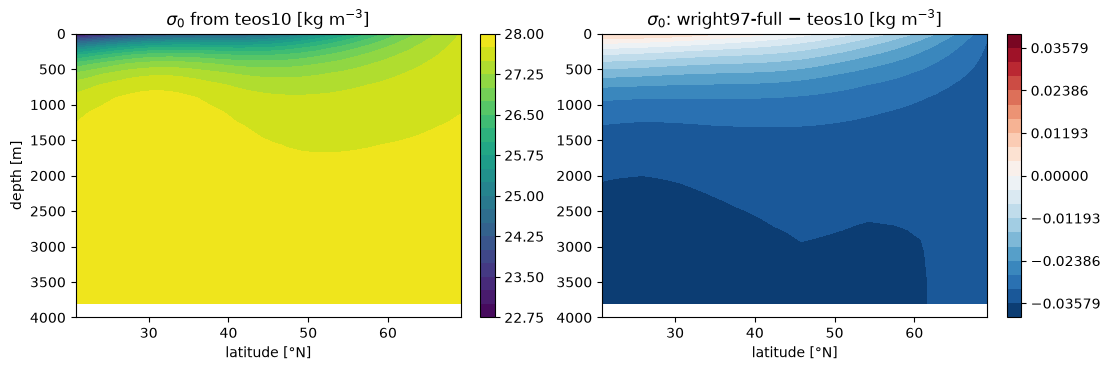

max |wright97-full - teos10| over the basin: 0.0415 kg/m3


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6), constrained_layout=True)

# A meridional section through the middle of the basin.
kw = dict(lon_c=lon_c[nx // 2], method="nearest")

cs = axes[0].contourf(lat_c, depth_c, sig["teos10"].sel(**kw), levels=21, cmap="viridis")
axes[0].set(title=r"$\sigma_0$ from teos10 [kg m$^{-3}$]",
            xlabel=r"latitude [$\degree$N]", ylabel="depth [m]", ylim=(4000, 0))
fig.colorbar(cs, ax=axes[0])

diff = (sig["wright97-full"] - sig["teos10"]).sel(**kw)
lim = float(abs(diff).max())
cs = axes[1].contourf(lat_c, depth_c, diff, levels=np.linspace(-lim, lim, 21), cmap="RdBu_r")
axes[1].set(title=r"$\sigma_0$: wright97-full $-$ teos10 [kg m$^{-3}$]",
            xlabel=r"latitude [$\degree$N]", ylim=(4000, 0))
fig.colorbar(cs, ax=axes[1])
plt.show()

print(f"max |wright97-full - teos10| over the basin: {float(abs(sig['wright97-full'] - sig['teos10']).max()):.4f} kg/m3")

The difference is small but structured, and it does not cancel. It is slightly *positive* in the
warm subtropical surface waters and grows steadily more *negative* with depth, reaching about
$-0.04$ kg m$^{-3}$ in the cold abyss — the two formulations disagree most about the compressibility
of cold, deep water. That is comparable to a typical density bin width, and it is systematically
signed rather than noisy, so it biases a transformation diagnostic rather than blurring it. This is
why matching your model's EOS matters.

### Naming your model's EOS directly with `xeos.from_model`

If you know which EOS your model was configured with, you probably know it by the model's *own*
name for it — `WRIGHT_FULL` in a MOM6 parameter file, `JMD95Z` in MITgcm's `data` namelist — rather
than by an `xeos` id. `xeos.from_model(model, selector)` translates for you:

In [14]:
print(xeos.list_models())

['MITGCM', 'MOM6', 'MPAS', 'OCEANANIGANS']


In [15]:
eos_mom6 = xeos.from_model("MOM6", "WRIGHT_FULL")
eos_mitgcm = xeos.from_model("MITgcm", "JMD95Z")

for name, eos in [("MOM6 WRIGHT_FULL", eos_mom6), ("MITgcm JMD95Z", eos_mitgcm)]:
    print(f"{name:>18s} -> xeos id {eos.id!r:18s} expects "
          f"{eos.temperature.name.lower()} temperature, "
          f"{eos.salinity.name.lower()} salinity")

  MOM6 WRIGHT_FULL -> xeos id 'wright97-full'    expects potential temperature, practical salinity
     MITgcm JMD95Z -> xeos id 'jmd95'            expects potential temperature, practical salinity


Each EOS also advertises the temperature and salinity *kinds* it expects, which is what section 5
is about. `xeos.selector_table()` lists every `(model, selector, xeos id)` triple it knows about,
and is the fastest way to find out whether your model's setting is covered.

### Bringing your own density: `eos=None`

If your model uses an EOS that `xeos` does not implement, or you have already diagnosed density and
the coefficients and want `xwmt` to use *exactly* those numbers, pass `eos=None`. `xwmt` then
computes nothing, and requires you to provide everything:

In [16]:
try:
    xwmt.WaterMass(
        grid, t_name="temp", s_name="salt", h_name="dz",
        eos=None, t_var="potential", s_var="practical",
    ).get_density("sigma0")
except ValueError as e:
    print(f"{type(e).__name__}: {e}")

ValueError: With `eos=None`, 'alpha' must already be present in `grid._ds` (got variables: ['area', 'dz', 'temp', 'salt', 'net_heat_flux', 'net_fw_flux', 'heat_tendency_surface', 'salt_tendency_surface', 'heat_tendency_diffusion', 'dz_i', 'z', 'z_interface']).


The contract is explicit: with `eos=None`, the variables `alpha`, `beta` and the requested density
(here `sigma0`) must already be in `grid._ds`. Note that the requirement is per *density name* — if
you also want `sigma2`, that must be present too.

As a demonstration, here is a linear equation of state,

$$\sigma_0 = \rho_0\left[1 - \alpha_0 (T - T_0) + \beta_0 (S - S_0)\right] - 1000,$$

with constant $\alpha_0$ and $\beta_0$, supplied by hand. This is exactly what you would do for an
idealized model that runs with such an EOS.

In [17]:
rho0, T0, S0 = 1027.0, 10.0, 35.0  # reference density [kg/m3] and T/S reference state
alpha0, beta0 = 1.7e-4, 7.6e-4     # [1/K], [kg/g]

ds_linear = ds.copy()
ds_linear["alpha"] = xr.full_like(ds.temp, alpha0)
ds_linear["beta"] = xr.full_like(ds.temp, beta0)
ds_linear["sigma0"] = rho0 * (1.0 - alpha0 * (ds.temp - T0) + beta0 * (ds.salt - S0)) - 1000.0

grid_linear = xgcm.Grid(ds_linear, coords=coords, metrics=metrics, padding=padding,
                        autoparse_metadata=False)

wm_linear = xwmt.WaterMass(
    grid_linear, t_name="temp", s_name="salt", h_name="dz",
    eos=None, t_var="potential", s_var="practical",
)
sigma0_linear = wm_linear.get_density("sigma0")

print("mean sigma0 (hand-supplied linear EOS):", float(sigma0_linear.mean()))

mean sigma0 (hand-supplied linear EOS): 27.47805168253712


`xwmt` returned our `sigma0` verbatim and left `alpha`/`beta` alone. The same honoring applies when
you pass a named `eos=` but want to override only the coefficients: if `alpha` and `beta` are
already in the dataset when `WaterMass` is constructed, they are used as-is and never overwritten.

## 5. Declaring what your temperature and salinity actually are

`t_var` and `s_var` tell `xwmt` what *kind* of temperature and salinity live in your dataset:

| keyword | options | `xwmt` default | typical non-MOM6 output |
| --- | --- | --- | --- |
| `t_var` | `"conservative"`, `"potential"`, `"in-situ"` | `"conservative"` | `"potential"` |
| `s_var` | `"absolute"`, `"practical"` | `"absolute"` | `"practical"` |

The defaults follow MOM6's convention, because MOM6 typically runs with TEOS-10 and carries
conservative temperature and absolute salinity as its prognostic tracers. Most other models — and
essentially all observational products and CMIP-era `thetao`/`so` archives — carry **potential
temperature and practical salinity** instead. That is why every `WaterMass` call in this notebook
passes `t_var="potential", s_var="practical"`.

These keywords do not change what `xwmt` reports; they change what it *feeds the EOS*. Each EOS
declares the kinds it expects (`eos.temperature`, `eos.salinity`, printed above), and `xwmt`
converts your inputs to those kinds with `gsw` — routing through absolute salinity and conservative
temperature as the conversion hubs, and skipping the conversion entirely when the kinds already
match. The `lon`/`lat` coordinates are what the practical-to-absolute salinity conversion needs.

For what these variables mean in ocean model output, and why the distinction is not pedantic,
see McDougall et al. (2021), *The interpretation of temperature and salinity variables in
numerical ocean model output and the calculation of heat fluxes and heat content*, Geoscientific
Model Development 14, 6445–6466,
[doi:10.5194/gmd-14-6445-2021](https://doi.org/10.5194/gmd-14-6445-2021).

This matters because getting it wrong fails *silently*. Nothing raises; you simply get the wrong
density. Feeding potential temperature to an EOS that expects conservative temperature is a real
and quiet error:

In [18]:
# The truth: our data are potential temperature and practical salinity.
sigma0_correct, _, _ = sigma0_under("teos10")

# The mistake: declaring them as conservative/absolute (the defaults), so xwmt performs no
# conversion and hands TEOS-10 the raw fields.
wm_wrong = xwmt.WaterMass(
    grid, t_name="temp", s_name="salt", h_name="dz",
    eos="teos10", t_var="conservative", s_var="absolute",
)
sigma0_wrong = wm_wrong.get_density("sigma0")

err = sigma0_wrong - sigma0_correct
print(f"mean error:  {float(err.mean()):+.4f} kg/m3")
print(f"max |error|: {float(abs(err).max()):.4f} kg/m3")

mean error:  -0.1331 kg/m3
max |error|: 0.1488 kg/m3


An error of order 0.1 kg m$^{-3}$ — larger than the differences between EOS formulations in
section 4, and larger than a typical density bin. Declare your kinds honestly.

## 6. `WaterMass` on its own

Everything so far has used `xwmt.WaterMass` directly, and it is worth pausing on that: not every
question requires a transformation. If you only want a consistent density and $\alpha$/$\beta$ on
your grid, `WaterMass` is the whole tool. It needs no `xbudget` recipe at all — only the grid and
the names of temperature, salinity and thickness.

In [19]:
wm = xwmt.WaterMass(
    grid,
    t_name="temp", s_name="salt", h_name="dz",
    eos="wright97-full",
    t_var="potential", s_var="practical",
    cp=CP, rho_ref=RHO_REF,
)

sigma0 = wm.get_density("sigma0")   # potential density anomaly, ref. 0 dbar
rho = wm.get_density("rho")         # in-situ density at the local pressure

print(f"sigma0 range: {float(sigma0.min()):.3f} to {float(sigma0.max()):.3f} kg/m3")
print(f"rho    range: {float(rho.min()):.3f} to {float(rho.max()):.3f} kg/m3")

sigma0 range: 22.951 to 27.882 kg/m3
rho    range: 1022.972 to 1045.223 kg/m3


Supported `density_name` values are `"rho"` (in-situ, at the local pressure) and `"sigma0"` through
`"sigma4"` (potential density anomaly referenced to 0, 1000, ..., 4000 dbar).

`WaterMass` also carries grid-aware helpers that depend on no budget at all. `get_outcrop_lev` and
`sel_outcrop_lev` find the shallowest non-vanishing layer in each column — the outcropping layer —
which is what you want for surface-referenced diagnostics in a layered model, where the top layer
of the array is not necessarily a real, non-zero-thickness cell.

In [20]:
temp_outcrop = wm.sel_outcrop_lev(grid._ds.temp)
print("outcropping temperature: shape", temp_outcrop.shape,
      f"| range {float(temp_outcrop.min()):.2f} to {float(temp_outcrop.max()):.2f} degC")

outcrop_depth = wm.get_outcrop_lev()
print("outcropping level depth: unique values", np.unique(outcrop_depth), "m")

outcropping temperature: shape (30, 30) | range 2.67 to 27.73 degC
outcropping level depth: unique values [5.] m


## 7. A generic tracer as $\lambda$

`xwmt` gives `heat` and `salt` special treatment — they are the two tracers that combine into
density — but the recipe is not limited to them. **Any** key other than `mass` is read
as a tracer, and its `lambda` can then be used as a transformation coordinate. This lets you ask
about transformation in oxygen space, in age space, in nutrient space, or in any tracer your model
carries.

Let us add oxygen. Our idealized `o2` field [µmol kg$^{-1}$] is set at the surface by solubility
(cold water holds more) and decreases downward through remineralization. Two processes act on it:
air-sea gas exchange restoring the top layer toward saturation, and interior remineralization
consuming it.

Watch the units. $\lambda$ is in µmol kg$^{-1}$, so by the rule in section 3 the tendencies must be
cell-integrated in µmol kg$^{-1}$ $\cdot$ kg s$^{-1}$ = µmol s$^{-1}$. `xwmt` applies no unit
conversion of its own to a generic tracer — no `cp` division, no factor of 1000 — so what you pass
is what it uses.

In [21]:
# Oxygen [umol/kg]: surface solubility decreasing with temperature, minus remineralization.
o2_sat = 350.0 - 6.0 * ds.temp.isel(depth_c=0)
ds["o2"] = o2_sat - 60.0 * (1.0 - np.exp(-ds.depth_c / 700.0))

# Air-sea gas exchange with a piston velocity, acting on the top layer only.
# k_w [m/s] * rho [kg/m3] * dO2 [umol/kg] * area [m2] -> umol/s.
k_w = 5.0e-5
ds["o2_tendency_gasex"] = (
    in_top_layer * k_w * RHO_REF * (o2_sat - ds.o2.isel(depth_c=0)) * ds.area
)

# Remineralization consumes oxygen, most strongly near the surface where the export flux
# attenuates. J [umol/kg/s] * rho [kg/m3] * dz [m] * area [m2] -> umol/s.
J_remin = (2.0 / (365.0 * 86400.0)) * np.exp(-ds.depth_c / 300.0)
ds["o2_tendency_remin"] = -J_remin * RHO_REF * ds.dz * ds.area

print(f"o2 range: {float(ds.o2.min()):.1f} to {float(ds.o2.max()):.1f} umol/kg")

o2 range: 123.9 to 333.5 umol/kg


Now extend the recipe with an `oxygen` entry. The key `"oxygen"` is arbitrary: it is
simply the name you will use to ask for it.

In [22]:
recipe_o2 = {
    **recipe,
    "oxygen": {
        "lambda": "o2",
        "rhs": {
            "air_sea_gas_exchange": "o2_tendency_gasex",
            "remineralization": "o2_tendency_remin",
        },
    },
}

grid = xgcm.Grid(ds, coords=coords, metrics=metrics, padding=padding, autoparse_metadata=False)

wmt = xwmt.WaterMassTransformations(
    grid, recipe_o2,
    eos="wright97-full", t_var="potential", s_var="practical",
    cp=CP, rho_ref=RHO_REF,
)

print("available lambdas:  ", wmt.lambdas())
print("available processes:", wmt.available_processes())

available lambdas:   ['temp', 'salt', 'o2', 'sigma0', 'sigma1', 'sigma2', 'sigma3', 'sigma4']
available processes: ['surface_exchange_flux', 'air_sea_gas_exchange', 'diffusion', 'remineralization']


Two things to notice.

First, `o2` appears alongside `temp` and `salt` as an available $\lambda$, and the five density
lambdas `sigma0`–`sigma4` are there too. The density lambdas are registered only when both `heat`
and `salt` are present in the recipe — density is derived from those two, so a
recipe containing only a custom tracer offers no density lambdas at all. If you want both, keep
`heat` and `salt` in it.

Second, `available_processes()` returns the union across tracers. Since `air_sea_gas_exchange` and
`remineralization` exist only for oxygen, we pass an explicit `term=` list below rather than letting
`xwmt` try every process on every tracer.

In [23]:
# Bin edges spanning the full range of `o2`. Our fields are zonally uniform, so there are
# only `ny` distinct surface values to bin: asking for many more bins than that would alias
# the result into a sawtooth rather than resolve it.
o2_bins = np.linspace(120.0, 340.0, 23)

wmt_o2 = wmt.integrate_transformations(
    "oxygen",
    term=["air_sea_gas_exchange", "remineralization"],
    bins=o2_bins,
)
wmt_o2

<xarray.Dataset> Size: 528B
Dimensions:               (o2_l_target: 22)
Coordinates:
  * o2_l_target           (o2_l_target) float64 176B 125.0 135.0 ... 325.0 335.0
Data variables:
    air_sea_gas_exchange  (o2_l_target) float64 176B -0.0 -0.0 ... -9.718e+08
    remineralization      (o2_l_target) float64 176B 2.743e+07 ... 1.081e+08

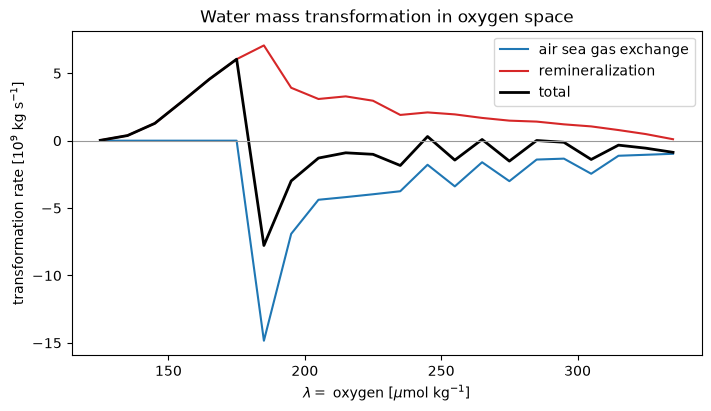

In [24]:
fig, ax = plt.subplots(figsize=(7, 4), constrained_layout=True)
lam = wmt_o2.o2_l_target

for name, color in [("air_sea_gas_exchange", "tab:blue"), ("remineralization", "tab:red")]:
    ax.plot(lam, wmt_o2[name] / 1e9, color=color, label=name.replace("_", " "))
ax.plot(lam, (wmt_o2.air_sea_gas_exchange + wmt_o2.remineralization) / 1e9,
        color="k", lw=2, label="total")

ax.axhline(0, color="0.6", lw=0.8)
ax.set(xlabel=r"$\lambda = $ oxygen [$\mu$mol kg$^{-1}$]",
       ylabel=r"transformation rate [$10^9$ kg s$^{-1}$]",
       title="Water mass transformation in oxygen space")
ax.legend()
plt.show()

The two processes separate cleanly, and they act over different ranges of oxygen because they act
at different depths: gas exchange only touches the undersaturated top layer, whose oxygen spans the
upper part of the range, while remineralization works throughout the oxygen-depleted interior.

**Mind the sign.** `xwmt` reports $\Omega(\lambda) = -\partial_\lambda \int \dot{\lambda}\,dV$, so a
process that *increases* the tracer appears as a *negative* transformation rate at the $\lambda$
values where it acts. Gas exchange oxygenates the surface layer — a positive tendency — hence the
negative blue curve; remineralization consumes oxygen — a negative tendency — hence the positive
red curve. The same convention governs density below, where surface heating (which *lightens*
water) gives a positive rate in the light classes.

For comparison, the same grid and the same recipe in density space, which uses the `heat` and
`salt` entries and the EOS chosen in section 4:

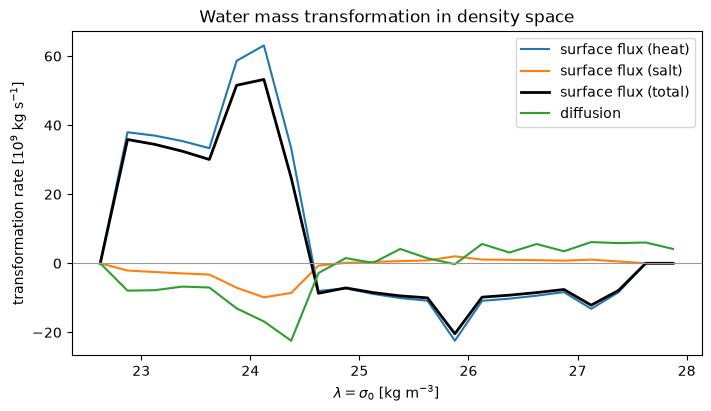

In [25]:
wmt_sigma0 = wmt.integrate_transformations("sigma0", bins=np.linspace(22.5, 28.0, 23))

fig, ax = plt.subplots(figsize=(7, 4), constrained_layout=True)
ax.plot(wmt_sigma0.sigma0_l_target, wmt_sigma0.surface_exchange_flux_heat / 1e9,
        label="surface flux (heat)")
ax.plot(wmt_sigma0.sigma0_l_target, wmt_sigma0.surface_exchange_flux_salt / 1e9,
        label="surface flux (salt)")
ax.plot(wmt_sigma0.sigma0_l_target, wmt_sigma0.surface_exchange_flux / 1e9,
        color="k", lw=2, label="surface flux (total)")
ax.plot(wmt_sigma0.sigma0_l_target, wmt_sigma0.diffusion / 1e9, label="diffusion")

ax.axhline(0, color="0.6", lw=0.8)
ax.set(xlabel=r"$\lambda = \sigma_0$ [kg m$^{-3}$]",
       ylabel=r"transformation rate [$10^9$ kg s$^{-1}$]",
       title="Water mass transformation in density space")
ax.legend()
plt.show()

Because both `heat` and `salt` contribute to density, `xwmt` reports each density process split into
`_heat` and `_salt` components as well as their sum.


## Summary

To point `xwmt` at your own model:

1. **Build an xgcm.Grid** with `coords` (`X`, `Y`, `Z`, the last with both `center` and `outer`),
   a `("X", "Y")` area metric, and `padding`. Your variable names are yours; nothing is hardcoded.
2. **Include lon/lat** as coordinates if your salinity needs converting — TEOS-10 takes absolute
   salinity, and the practical-to-absolute conversion is the only thing that asks for them. Use
   `xwmt.add_gridcoords` to extend a grid you have already built.
3. **Write the xbudget recipe by hand.** `mass` with a `thickness`, then one entry per tracer
   with a `lambda` and its `lhs`/`rhs` processes. Tendencies must be **cell-integrated**: W for
   heat, kg s$^{-1}$ for salt, and $\lambda$-units $\times$ kg s$^{-1}$ for anything else.
4. **Choose your EOS with eos=** — a name from `xwmt.eos.list_eos()`, an object from
   `xeos.from_model(...)`, or `None` together with your own `alpha`/`beta`/density. Never `teos10=`.
5. **Declare t_var/s_var.** Non-MOM6 output is almost always `"potential"`/`"practical"`, and
   the defaults are not.

`WaterMass` alone gets you density, $\alpha$ and $\beta$ with no `xbudget` recipe at all; add the
recipe and `WaterMassTransformations` when you want the transformation rates themselves.